In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# lib of sklearn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score


import pickle



In [103]:
data = load_iris()
print(type(data))
df = pd.DataFrame(data = data.data, columns=data.feature_names)
# df = load_iris(as_frame=True).frame
df.head()

<class 'sklearn.utils._bunch.Bunch'>


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [104]:
df['species'] = data.target
df['species_name'] = df['species'].apply(lambda x: data.target_names[x])
df.head()
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [105]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [106]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

In [107]:
df.shape
df = df.astype({'species': 'category', 'species_name': 'category'})
df.dtypes

sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
species_name         category
dtype: object

In [108]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [109]:
df.boxplot()

<Axes: >

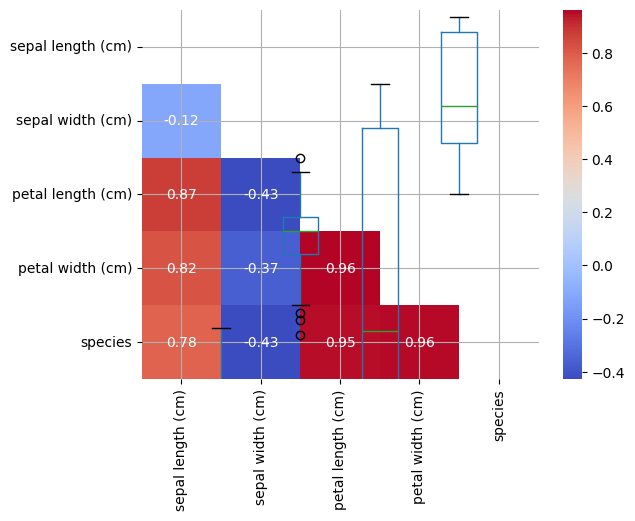

In [110]:
cr = df.drop('species_name', axis=1).corr()
cr
msk = np.triu(np.ones_like(cr, dtype=bool))
sns.heatmap(cr, annot=True, cmap='coolwarm', mask=msk)

plt.show()

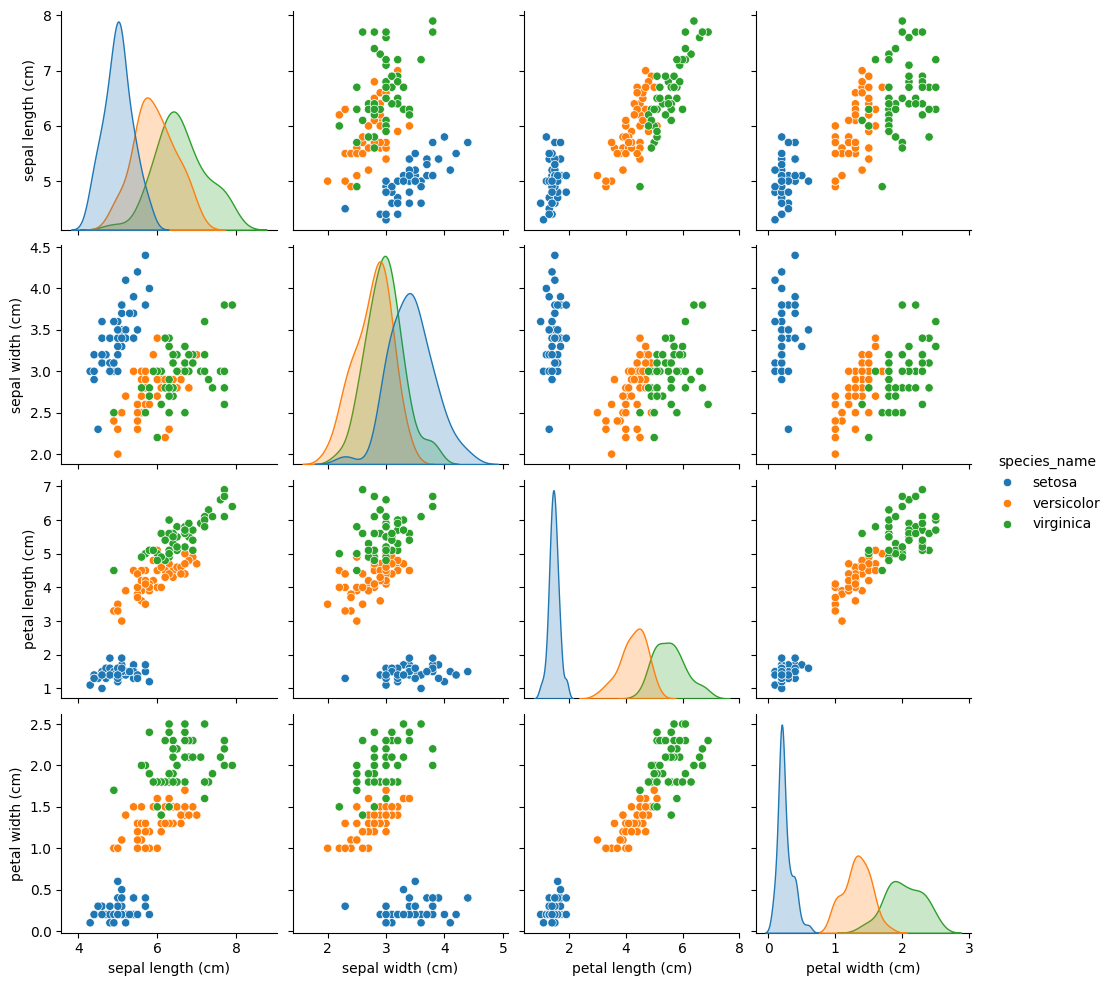

In [111]:
sns.pairplot(df, hue='species_name')
plt.show()

In [112]:
px.box(df, y=['sepal length (cm)','sepal width (cm)', 'petal length (cm)', 'petal width (cm)'],  color='species_name')

In [113]:
px.scatter_3d(df, x='sepal length (cm)', y='sepal width (cm)', z='petal length (cm)', color='species_name')

In [114]:
sc = StandardScaler()
X_scaled = sc.fit_transform(df.drop(['species', 'species_name'], axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=df.columns[:-2],index=df.index)
df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [115]:
sc = StandardScaler().set_output(transform="pandas")
X_scaled = sc.fit_transform(df.drop(['species', 'species_name'], axis=1))
X_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [116]:
df_scaled = X_scaled.join(df[['species', 'species_name']])
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,-0.900681,1.019004,-1.340227,-1.315444,0,setosa
1,-1.143017,-0.131979,-1.340227,-1.315444,0,setosa
2,-1.385353,0.328414,-1.397064,-1.315444,0,setosa
3,-1.506521,0.098217,-1.283389,-1.315444,0,setosa
4,-1.021849,1.249201,-1.340227,-1.315444,0,setosa


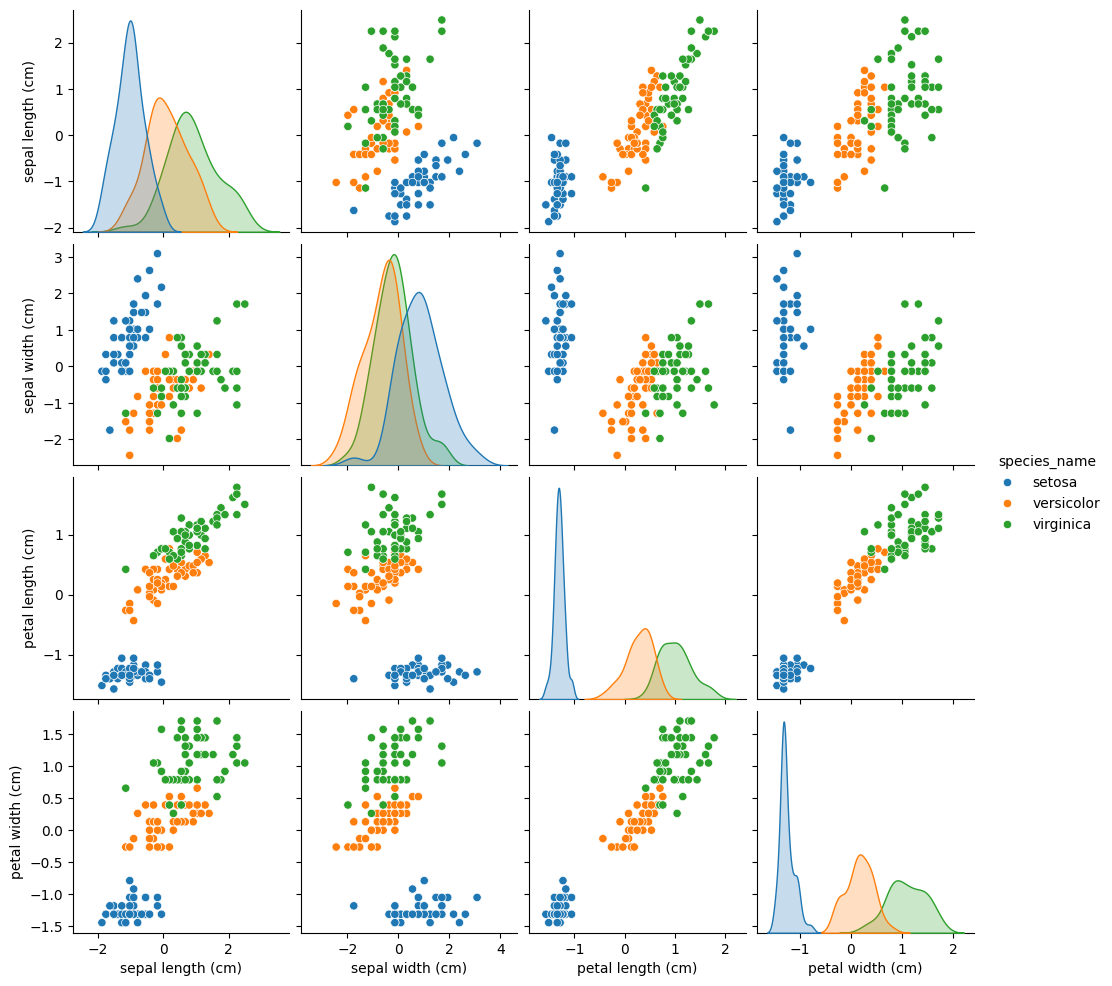

In [117]:
sns.pairplot(df_scaled, hue='species_name')
plt.show()

In [138]:
model_1 = MLPClassifier(hidden_layer_sizes=(50,10),  solver='adam', early_stopping=True, max_iter=1000, n_iter_no_change=20, tol=1e-6, verbose=True, random_state=42)
model_2 = MLPClassifier(hidden_layer_sizes=(100,), early_stopping=True, max_iter=1000, n_iter_no_change=20, tol=1e-4, verbose=True, random_state=42)
clf = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(3, 3), random_state=1)


In [139]:
clf.fit(X_scaled, df_scaled['species'])

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(3, ...)"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [140]:
X = df_scaled.drop(['species', 'species_name'], axis=1)
y = df_scaled['species']
# y2 = df_scaled['species_name']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y2, test_size=0.2, random_state=42)
model_1.fit(X_train, y_train)
model_1.score(X_test, y_test)
model_1.score(X_train, y_train)
# model_2.fit(X_train_2, y_train_2)

Iteration 1, loss = 1.40691466
Validation score: 0.250000
Iteration 2, loss = 1.38433706
Validation score: 0.250000
Iteration 3, loss = 1.36225797
Validation score: 0.250000
Iteration 4, loss = 1.34084288
Validation score: 0.250000
Iteration 5, loss = 1.31999101
Validation score: 0.250000
Iteration 6, loss = 1.29951440
Validation score: 0.250000
Iteration 7, loss = 1.27957347
Validation score: 0.250000
Iteration 8, loss = 1.26002327
Validation score: 0.250000
Iteration 9, loss = 1.24086118
Validation score: 0.250000
Iteration 10, loss = 1.22218220
Validation score: 0.250000
Iteration 11, loss = 1.20397486
Validation score: 0.250000
Iteration 12, loss = 1.18620545
Validation score: 0.250000
Iteration 13, loss = 1.16886842
Validation score: 0.250000
Iteration 14, loss = 1.15183263
Validation score: 0.250000
Iteration 15, loss = 1.13516195
Validation score: 0.250000
Iteration 16, loss = 1.11902080
Validation score: 0.250000
Iteration 17, loss = 1.10316048
Validation score: 0.250000
Iterat

0.8416666666666667

In [141]:
model_1.predict(X_test)
print(classification_report(y_test, model_1.predict(X_test)))

plt.show()

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      0.56      0.71         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.82      0.83        30
weighted avg       0.89      0.83      0.83        30

